In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score,mean_absolute_error,silhouette_score,accuracy_score,confusion_matrix
import pickle

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
df1 = pd.read_excel('/content/drive/MyDrive/Customer Lifetime Value/online_retail_II.xlsx',sheet_name='Year 2009-2010')

In [52]:
df2 = pd.read_excel('/content/drive/MyDrive/Customer Lifetime Value/online_retail_II.xlsx',sheet_name='Year 2010-2011')

In [53]:
df = pd.concat([df1,df2])

In [54]:
df.shape

(1067371, 8)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


In [56]:
df = df[~df['Customer ID'].isna()]

In [57]:
df = df[df['Quantity'] > 0]

In [58]:
df.columns = df.columns.str.replace(' ','_')

In [59]:
df['Revenue'] = df['Price'] * df['Quantity']

In [60]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [61]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('Customer_ID').agg({
    'InvoiceDate': [
        lambda x: (snapshot_date - x.max()).days,   # Recency
        lambda x: (x.max() - x.min()).days          # Tenure
    ],
    'Invoice': 'nunique',                           # Frequency
    'Revenue': 'sum'
})

customer_df.columns = ['Recency','Tenure','Frequency','Monetary']
customer_df = customer_df.reset_index()

In [62]:
customer_df['AOV'] = customer_df['Monetary'] / customer_df['Frequency']

In [63]:
customer_df['Purchase_Interval'] = customer_df['Tenure'] / customer_df['Frequency']

In [64]:
#CLV
customer_df['CLV'] = customer_df['AOV'] * customer_df['Frequency'] * customer_df['Tenure']

In [65]:
# CLV Prediction
X = customer_df[['Recency','Frequency','Monetary','AOV','Tenure','Purchase_Interval']]
y = customer_df['CLV']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

clv_model = RandomForestRegressor()
clv_model.fit(X_train,y_train)

RandomForestRegressor()

In [66]:
train_pred = clv_model.predict(X_train)
print("r2 score: ",r2_score(y_train,train_pred))

r2 score:  0.9757928551912661


In [67]:
pred = clv_model.predict(X_test)
print("r2 score: ",r2_score(y_test,pred))
print("Mean Absolute Error: ",mean_absolute_error(y_test,pred))

r2 score:  0.911079727203438
Mean Absolute Error:  187010.9600342222


In [68]:
# Customer Segmentation
features = customer_df[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

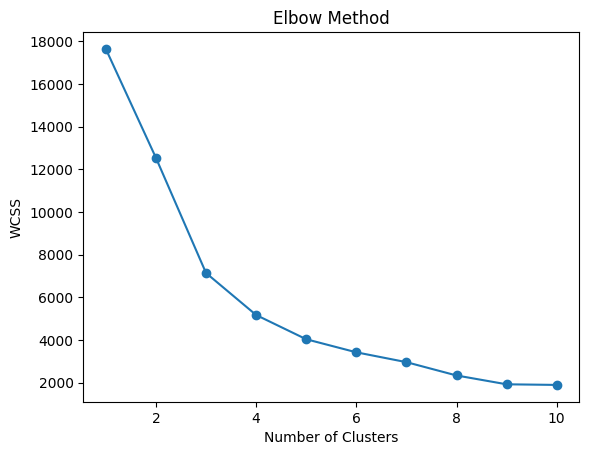

In [80]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [70]:
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled)
    score = silhouette_score(scaled, labels)
    print(k, score)

2 0.5567895552453249
3 0.5828276853871412
4 0.5905397471403384
5 0.60778672075446
6 0.5454098628402806
7 0.5488758476386262
8 0.549476596541435
9 0.5090903364599841


In [71]:
# number of clusters 5
kmeans_model = KMeans(n_clusters=5, random_state=42)
customer_df['Segment'] = kmeans_model.fit_predict(scaled)

<Axes: xlabel='Segment', ylabel='Monetary'>

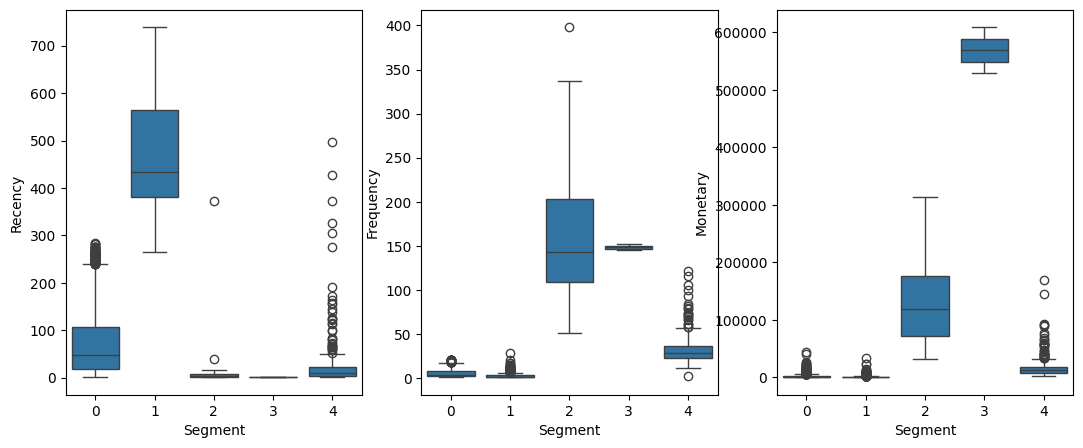

In [72]:
plt.figure(figsize=(13,5))
plt.subplot(1,3,1)
sns.boxplot(data=customer_df,x='Segment',y='Recency')
plt.subplot(1,3,2)
sns.boxplot(data=customer_df,x='Segment',y='Frequency')
plt.subplot(1,3,3)
sns.boxplot(data=customer_df,x='Segment',y='Monetary')

In [73]:
segment_map = {
3:'High Value',
2:'Loyal',
0:'At Risk',
4:'Low Engagement',
1:'Churned'
}

customer_df['Segment_Label'] = customer_df['Segment'].map(segment_map)

In [74]:
#creating Churn Classification
customer_df['Churn'] = np.where(customer_df['Recency'] > 30, 1, 0)

In [75]:
X = customer_df[['Recency','Frequency','Monetary','Tenure','AOV']]
y = customer_df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

churn_model = RandomForestClassifier()
churn_model.fit(X_train,y_train)

customer_df['Churn_Prob'] = churn_model.predict_proba(X)[:,1]

In [76]:
customer_df['CLV'].median()

180145.68

In [77]:
# Business Recommendation
def recommendation(row):
    if row['Segment_Label'] == 'High Value' and row['CLV'] > 1000000 and row['Churn_Prob'] > 0.6:
        return "VIP Retention Campaign"
    elif row['Segment_Label'] == 'High Value':
        return "Premium Loyalty Program"
    elif row['Segment_Label'] == 'Loyal':
        return "Upsell / Product Bundles"
    elif row['Segment_Label'] == 'At Risk':
        return "Discount Win-Back Campaign"
    elif row['Segment_Label'] == 'Low Engagement':
        return "Personalized Recommendations"
    elif row['Segment_Label'] == 'Churned':
        return "Reactivation Email Campaign"
    else:
        return "General Promotion"

customer_df['Strategy'] = customer_df.apply(recommendation,axis=1)

In [78]:
customer_df

,Customer_ID,Recency,Tenure,Frequency,Monetary,AOV,Purchase_Interval,CLV,Segment,Segment_Label,Churn,Churn_Prob,Strategy
0,12346.0,326,400,12,77556.46,6463.038333,33.333333,31022584.00,4,Low Engagement,1,1.00,Personalized Recommendations
1,12347.0,2,402,8,5633.32,704.165000,50.250000,2264594.64,0,At Risk,0,0.01,Discount Win-Back Campaign
2,12348.0,75,362,5,2019.40,403.880000,72.400000,731022.80,0,At Risk,1,1.00,Discount Win-Back Campaign
3,12349.0,19,570,4,4428.69,1107.172500,142.500000,2524353.30,0,At Risk,0,0.00,Discount Win-Back Campaign
4,12350.0,310,0,1,334.40,334.400000,0.000000,0.00,1,Churned,1,1.00,Reactivation Email Campaign
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5876,18283.0,4,654,22,2736.65,124.393182,29.727273,1789769.10,4,Low Engagement,0,0.00,Personalized Recommendations
5877,18284.0,432,0,1,461.68,461.680000,0.000000,0.00,1,Churned,1,1.00,Reactivation Email Campaign
5878,18285.0,661,0,1,427.00,427.000000,0.000000,0.00,1,Churned,1,1.00,Reactivation Email Campaign
5879,18286.0,477,247,2,1296.43,648.215000,123.500000,320218.21,1,Churned,1,1.00,Reactivation Email Campaign


In [83]:
pickle.dump(clv_model, open("clv_model.pkl","wb"))
pickle.dump(churn_model, open("churn_model.pkl","wb"))
pickle.dump(kmeans_model, open("kmeans_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))